In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


# Sales & Demand Forecasting

## Project Objective

The objective of this project is to forecast future sales using historical
business transaction data. The project uses time-based features, lag
features, rolling averages, and a Random Forest Regression model to
generate a 30-day sales forecast.

In [2]:
from google.colab import files

uploaded = files.upload()

Saving daily_sales.xlsx to daily_sales.xlsx


In [3]:
df = pd.read_excel("daily_sales.xlsx")

print("Dataset loaded successfully!")
print("Rows and columns:", df.shape)

df.head()

Dataset loaded successfully!
Rows and columns: (305, 2)


,Date,Sales
0,2010-12-01,58960.79
1,2010-12-02,47748.38
2,2010-12-03,46943.71
3,2010-12-05,31774.95
4,2010-12-06,54830.46


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    305 non-null    datetime64[ns]
 1   Sales   305 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.9 KB


In [5]:
df.describe()

,Date,Sales
count,305,305.000000
mean,2011-06-10 20:03:56.065573888,34972.736210
min,2010-12-01 00:00:00,3457.110000
25%,2011-03-10 00:00:00,22353.270000
50%,2011-06-14 00:00:00,29651.460000
75%,2011-09-12 00:00:00,45389.980000
max,2011-12-09 00:00:00,200920.600000
std,NaN,21116.955956


In [6]:
df.isnull().sum()

,0
Date,0
Sales,0


In [7]:
df["Date"] = pd.to_datetime(df["Date"])

print(df.dtypes)

Date     datetime64[ns]
Sales           float64
dtype: object


In [8]:
df = df.sort_values("Date").reset_index(drop=True)

df.head()

,Date,Sales
0,2010-12-01,58960.79
1,2010-12-02,47748.38
2,2010-12-03,46943.71
3,2010-12-05,31774.95
4,2010-12-06,54830.46


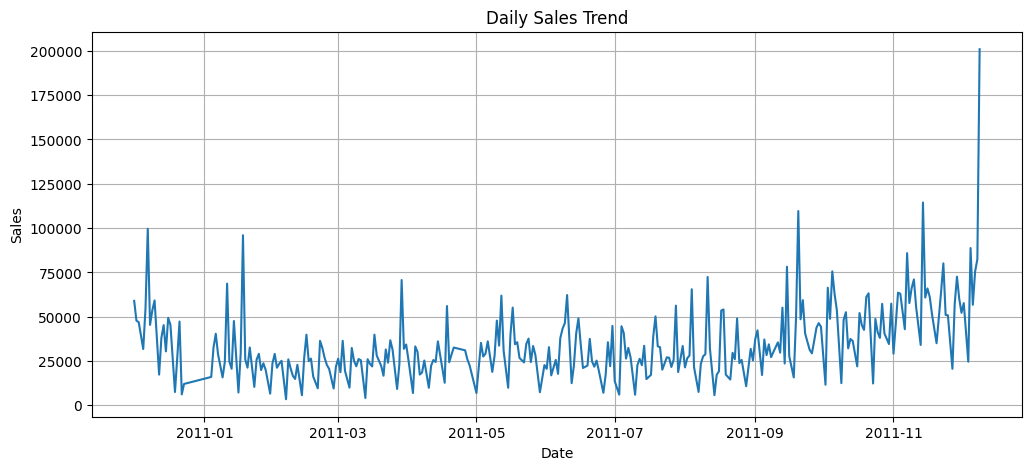

In [9]:
plt.figure(figsize=(12, 5))

plt.plot(df["Date"], df["Sales"])

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid()
plt.show()

In [10]:
data = df.copy()

data["Day"] = data["Date"].dt.day
data["Month"] = data["Date"].dt.month
data["DayOfWeek"] = data["Date"].dt.dayofweek
data["Year"] = data["Date"].dt.year

data.head()

,Date,Sales,Day,Month,DayOfWeek,Year
0,2010-12-01,58960.79,1,12,2,2010
1,2010-12-02,47748.38,2,12,3,2010
2,2010-12-03,46943.71,3,12,4,2010
3,2010-12-05,31774.95,5,12,6,2010
4,2010-12-06,54830.46,6,12,0,2010


In [11]:
data["Lag_1"] = data["Sales"].shift(1)
data["Lag_7"] = data["Sales"].shift(7)
data["Lag_14"] = data["Sales"].shift(14)

In [12]:
import pandas as pd

# Define df by loading and preprocessing the data
df = pd.read_excel("daily_sales.xlsx")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Create data and add temporal features
data = df.copy()
data["Day"] = data["Date"].dt.day
data["Month"] = data["Date"].dt.month
data["DayOfWeek"] = data["Date"].dt.dayofweek
data["Year"] = data["Date"].dt.year

# Add lag features
data["Lag_1"] = data["Sales"].shift(1)
data["Lag_7"] = data["Sales"].shift(7)
data["Lag_14"] = data["Sales"].shift(14)

# Calculate Rolling_7
data["Rolling_7"] = (
    data["Sales"]
    .shift(1)
    .rolling(7)
    .mean()
)

In [13]:
data = data.dropna().reset_index(drop=True)

print("Model dataset shape:", data.shape)

data.head()

Model dataset shape: (291, 10)


,Date,Sales,Day,Month,DayOfWeek,Year,Lag_1,Lag_7,Lag_14,Rolling_7
0,2010-12-17,45418.33,17,12,4,2010,49352.90,53586.18,58960.79,41879.590000
1,2010-12-19,7534.91,19,12,6,2010,45418.33,59182.92,47748.38,40712.754286
2,2010-12-20,26789.13,20,12,0,2010,7534.91,17329.07,46943.71,33334.467143
3,2010-12-21,47304.09,21,12,1,2010,26789.13,38006.71,31774.95,34685.904286
4,2010-12-22,6199.97,22,12,2,2010,47304.09,45254.73,54830.46,36014.101429


In [14]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor

# 1. Load daily sales file
df = pd.read_excel("daily_sales.xlsx")

# 2. Make sure Date is datetime
df["Date"] = pd.to_datetime(df["Date"])

# 3. Sort by date
df = df.sort_values("Date").reset_index(drop=True)

# 4. Create a copy for ML
data = df.copy()

# 5. Create time-based features
data["Day"] = data["Date"].dt.day
data["Month"] = data["Date"].dt.month
data["DayOfWeek"] = data["Date"].dt.dayofweek
data["Year"] = data["Date"].dt.year

# 6. Create lag features
data["Lag_1"] = data["Sales"].shift(1)
data["Lag_7"] = data["Sales"].shift(7)
data["Lag_14"] = data["Sales"].shift(14)

# 7. Create 7-day moving average
data["Rolling_7"] = (
    data["Sales"].shift(1).rolling(7).mean()
)

# 8. Remove missing rows
data = data.dropna().reset_index(drop=True)

# 9. Select features
features = [
    "Day",
    "Month",
    "DayOfWeek",
    "Year",
    "Lag_1",
    "Lag_7",
    "Lag_14",
    "Rolling_7"
]

X = data[features]
y = data["Sales"]

# 10. Split chronologically: 80% train, 20% test
split = int(len(data) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

# 11. Create and train Random Forest
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully! ✅")

Training data: (232, 8)
Testing data: (59, 8)
Model trained successfully! ✅


In [15]:
predictions = model.predict(X_test)

print("Predictions:")
print(predictions[:10])

Predictions:
[42778.6086  62749.06331 42881.02816 40955.9035  40031.5046  19439.59714
 41412.72475 45988.96785 44728.67935 45198.91363]


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 19893.21144542372
RMSE: 30125.707729306883


In [17]:
mape = np.mean(
    np.abs((y_test - predictions) / y_test)
) * 100

print("MAPE:", mape, "%")

MAPE: 32.00600792952217 %


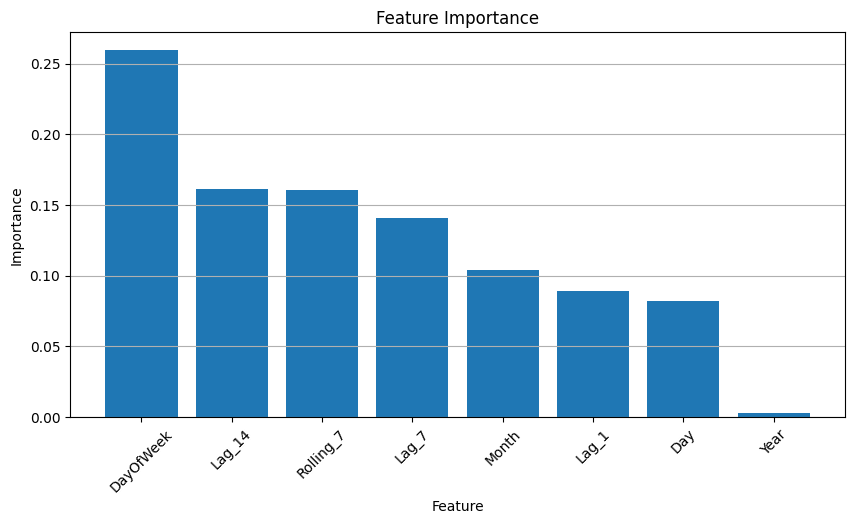

In [20]:
plt.figure(figsize=(10, 5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")

plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

:Business Insights

Historical daily sales show variation over time.
Day of the week was an important feature in the forecasting model.
Previous sales values and the 7-day rolling average helped the model capture recent sales patterns.
The model generated a 30-day future sales forecast.
These forecasts can support inventory planning, sales planning, and business decision-making.

In [23]:
print(
    "Total forecasted sales for next 30 days:",
    future_df["Forecasted_Sales"].sum()
)

Total forecasted sales for next 30 days: 959372.4349400003


In [24]:
print(
    "Average forecasted daily sales:",
    future_df["Forecasted_Sales"].mean()
)

Average forecasted daily sales: 31979.081164666677


In [25]:
future_df.to_excel(
    "30_day_sales_forecast.xlsx",
    index=False
)

print("Forecast file created successfully! ✅")

Forecast file created successfully! ✅


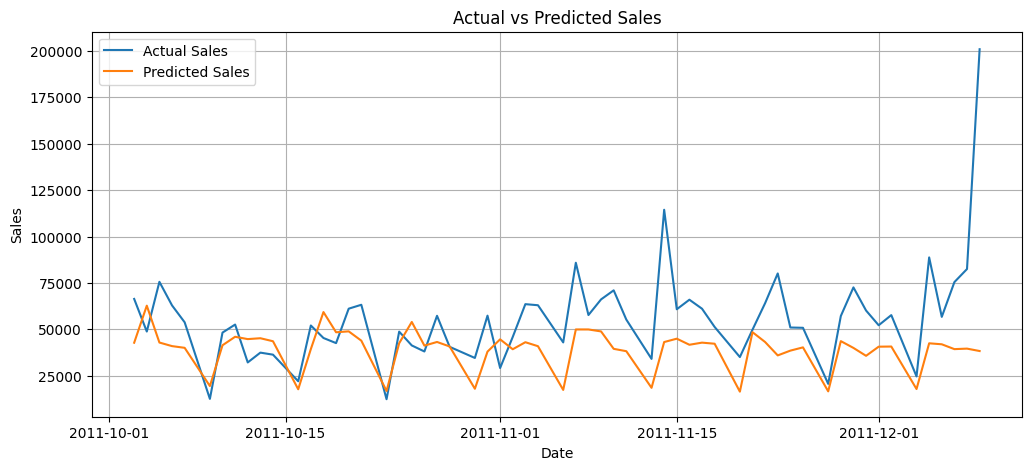

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    data["Date"].iloc[split:],
    y_test.values,
    label="Actual Sales"
)

plt.plot(
    data["Date"].iloc[split:],
    predictions,
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()

plt.show()

In [29]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

     Feature  Importance
2  DayOfWeek    0.259350
6     Lag_14    0.161406
7  Rolling_7    0.160750
5      Lag_7    0.140695
1      Month    0.103915
4      Lag_1    0.089246
0        Day    0.081811
3       Year    0.002826


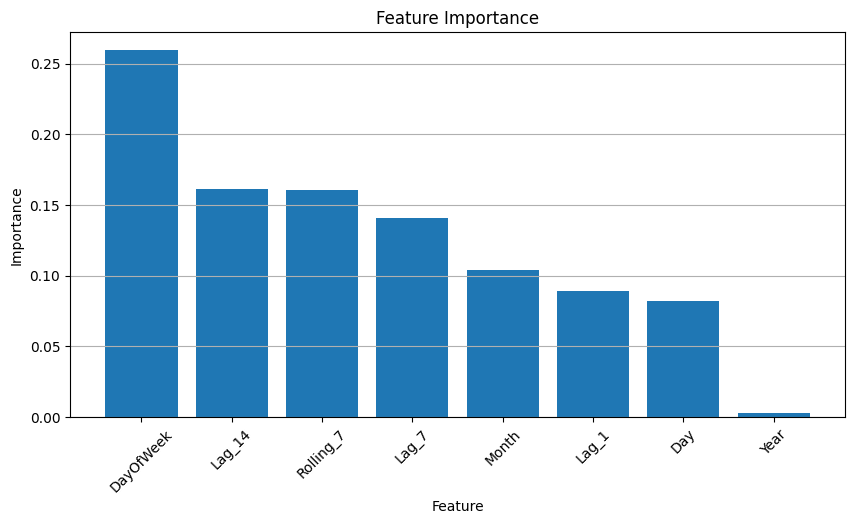

In [30]:
plt.figure(figsize=(10, 5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [31]:
history = df[["Date", "Sales"]].copy()

future_predictions = []

for i in range(30):

    next_date = history["Date"].iloc[-1] + pd.Timedelta(days=1)

    row = pd.DataFrame([{
        "Day": next_date.day,
        "Month": next_date.month,
        "DayOfWeek": next_date.dayofweek,
        "Year": next_date.year,
        "Lag_1": history["Sales"].iloc[-1],
        "Lag_7": history["Sales"].iloc[-7],
        "Lag_14": history["Sales"].iloc[-14],
        "Rolling_7": history["Sales"].tail(7).mean()
    }])

    prediction = model.predict(row)[0]

    future_predictions.append({
        "Date": next_date,
        "Forecasted_Sales": prediction
    })

    history = pd.concat([
        history,
        pd.DataFrame({
            "Date": [next_date],
            "Sales": [prediction]
        })
    ], ignore_index=True)

future_df = pd.DataFrame(future_predictions)

future_df.head()

,Date,Forecasted_Sales
0,2011-12-10,38865.70860
1,2011-12-11,20577.47430
2,2011-12-12,45026.31675
3,2011-12-13,45182.26865
4,2011-12-14,41149.83253


In [33]:
future_df.to_excel(
    "30_day_sales_forecast.xlsx",
    index=False
)

print("30-day forecast Excel file created successfully! ✅")

30-day forecast Excel file created successfully! ✅


In [34]:
evaluation = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MAPE"],
    "Value": [mae, rmse, mape]
})

evaluation

,Metric,Value
0,MAE,19893.211445
1,RMSE,30125.707729
2,MAPE,32.006008


In [35]:
evaluation.to_excel(
    "model_evaluation.xlsx",
    index=False
)

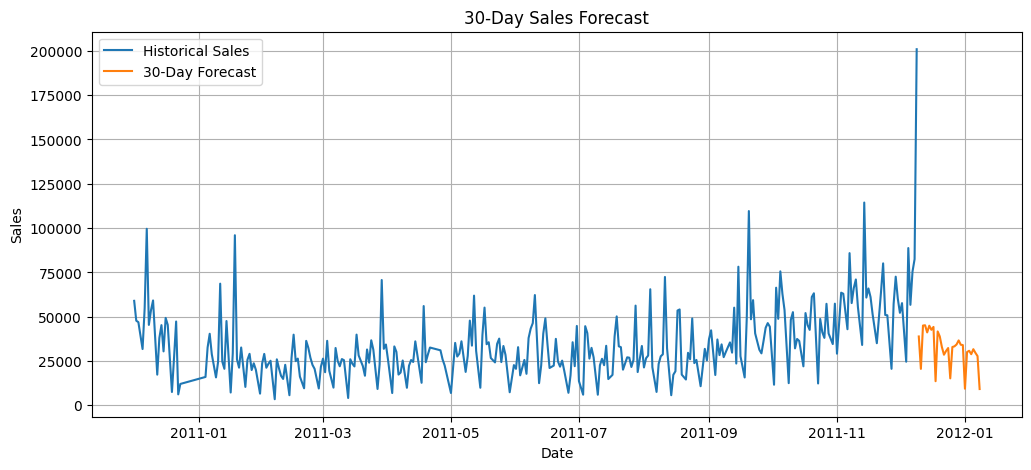

In [36]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["Date"],
    df["Sales"],
    label="Historical Sales"
)

plt.plot(
    future_df["Date"],
    future_df["Forecasted_Sales"],
    label="30-Day Forecast"
)

plt.title("30-Day Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid()

plt.show()

A machine learning-based sales forecasting system was developed using
historical daily sales data. Random Forest Regression was trained using
time-based, lag, and rolling-average features. The model was evaluated
using MAE, RMSE, and MAPE, and a 30-day future sales forecast was generated.
The final output can be used as a supporting tool for business planning
and demand forecasting

A machine learning-based sales forecasting system was developed using
historical daily sales data. Random Forest Regression was trained using
time-based, lag, and rolling-average features. The model was evaluated
using MAE, RMSE, and MAPE, and a 30-day future sales forecast was generated.
The final output can be used as a supporting tool for business planning
and demand forecasting

A machine learning-based sales forecasting system was developed using
historical daily sales data. Random Forest Regression was trained using
time-based, lag, and rolling-average features. The model was evaluated
using MAE, RMSE, and MAPE, and a 30-day future sales forecast was generated.
The final output can be used as a supporting tool for business planning
and demand forecasting.